In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# define basic logic gates
X = torch.tensor([[0,0], [0,1], [1,0], [1,1]], dtype=torch.float32)
gates = ( "XOR")
# labels
#Y_or = torch.tensor([0, 1, 1, 1], dtype=torch.float32).view(-1, 1)
#Y_and = torch.tensor([0, 0, 0, 1], dtype=torch.float32).view(-1, 1)
Y_xor = torch.tensor([0, 1, 1, 0], dtype=torch.float32).view(-1, 1)

class PerceptronDeep(torch.nn.Module):
    # constructor
    def __init__(self, hidden_size):
        super(PerceptronDeep, self).__init__()
        self.hidden_layer = nn.Linear(2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    # mathod called once the model is executed
    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.sigmoid(x)
        x = self.output_layer(x)
        return self.sigmoid(x)


MSE = nn.MSELoss()

# train
N_epochs = 100000

for gate, y_gt in zip(gates, (Y_xor)):
    # define model and learnig scheme
    model = PerceptronDeep(hidden_size=2)
    optimizer = optim.SGD(model.parameters(), lr=0.5)
    # start training
    train_loss = []
    model.train()  # turn on the training mode
    for _ in range(N_epochs):
        if(_ % 10000 == 0):
            print("epoch = ", _)
        # this will zero out the gradients for this batch
        optimizer.zero_grad()
        # make predictions
        y_pred = model(X)
        # calculate the MSE loss
        loss = MSE(y_pred, y_gt)
        # backpropagate the loss
        loss.backward()
        # update the model weights (with assumed learning rate)
        optimizer.step()
        train_loss.append(loss.item())
    print("last loss value = ", train_loss[-1])
    model.eval()
    for i, x in enumerate(X):
        print("{} {} {} -> {}".format(x[0].item(), gate, x[1].item(), model(x).item()))
    print()


last loss value =  1.7761494746082462e-05
0.0 OR 0.0 -> 0.0062625473365187645
0.0 OR 1.0 -> 0.9962961077690125
1.0 OR 0.0 -> 0.9958494901657104
1.0 OR 1.0 -> 0.999061644077301

last loss value =  1.5958277799654752e-05
0.0 AND 0.0 -> 0.00025506989913992584
0.0 AND 1.0 -> 0.004040976520627737
1.0 AND 0.0 -> 0.004038860090076923
1.0 AND 1.0 -> 0.9944209456443787

last loss value =  5.161215813132003e-05
0.0 XOR 0.0 -> 0.0065903617069125175
0.0 XOR 1.0 -> 0.9931696653366089
1.0 XOR 0.0 -> 0.9931721687316895
1.0 XOR 1.0 -> 0.008351050317287445



In [ ]:

### wizualizacja przestrzeni X1 x X2 ###
##  jak narysować powierzchnie graniczną dla XORA ##

## wyciaganie wag i biasów z modelu
W = model.hidden_layer.weight.detach().cpu().numpy().copy()
b = model.hidden_layer.bias.detach().cpu().numpy().copy()

v = model.output_layer.weight.detach().cpu().numpy().copy()[0]
c = model.output_layer.bias.detach().cpu().item()

print("Wagi warstwy ukrytej:\n", W)
print("Biasy warstwy ukrytej:\n", b)
print("Wagi warstwy wyjściowej:\n", v)
print("Bias warstwy wyjściowej:\n", c)

# Każdy wiersz W odpowiada jednemu 
# neuronowi ukrytemu, a kolumny — wejściom \(x_1,x_2\).

# h_1 = sigmoid(W_11*X_1 + W12*X2 + b1) pierwszy neuron ukryty
# h_2 = sigmoid(W_21*X_1 + W22*X2 + b2) drugi neuron ukryty
# y~ = sigmoid(v1*h1 + v2*h2 + c) wyjscie z sieci


Wagi warstwy ukrytej:
 [[-6.7708077 -6.7643995]
 [-5.3867793 -5.3853073]]
Biasy warstwy ukrytej:
 [2.8402114 8.037494 ]
Wagi warstwy wyjściowej:
 [-11.609816  11.430805]
Bias warstwy wyjściowej:
 -5.473571300506592


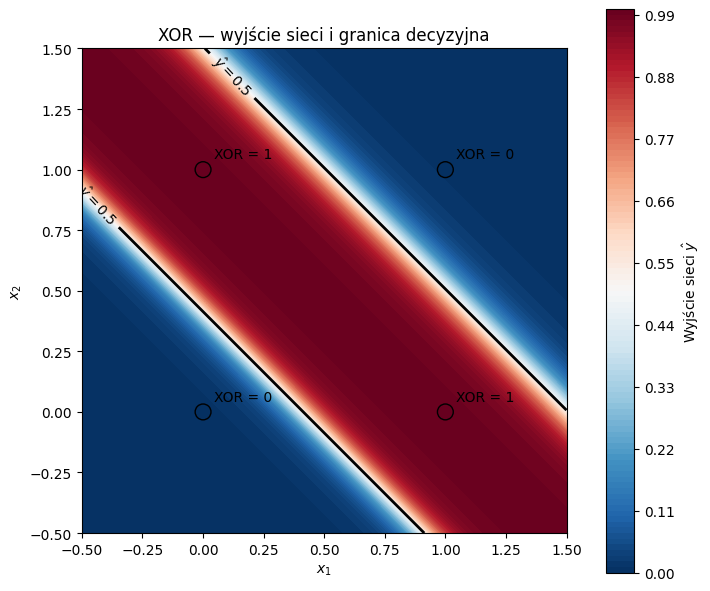

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    # Numerycznie stabilna postać sigmoidy
    return 0.5 * (1 + np.tanh(z / 2))

axis = np.linspace(-0.5, 1.5, 401)
x1, x2 = np.meshgrid(axis, axis)
h1 = sigmoid(W[0, 0] * x1 + W[0, 1] * x2 + b[0])
h2 = sigmoid(W[1, 0] * x1 + W[1, 1] * x2 + b[1])
z = v[0] * h1 + v[1] * h2 + c
output = sigmoid(z)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
image = ax.contourf(
    x1, x2, output,
    levels=np.linspace(0, 1, 101),
    cmap="RdBu_r",
    vmin=0, vmax=1,
)
fig.colorbar(image, ax=ax, label=r"Wyjście sieci $\hat{y}$")

boundary = ax.contour(
    x1, x2, z,
    levels=[0],
    colors="black",
    linewidths=2,
)
ax.clabel(boundary, fmt={0: r"$\hat{y}=0.5$"})

ax.set(
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    title="XOR — wyjście sieci i granica decyzyjna",
)
ax.set_aspect("equal")

### od chata punkty jakos zaznaczone ###
# Cztery punkty treningowe, pokolorowane według poprawnej klasy
points = X.detach().cpu().numpy()
labels = Y_xor.detach().cpu().numpy().ravel()

ax.scatter(
    points[:, 0], points[:, 1],
    c=labels, cmap="RdBu_r", vmin=0, vmax=1,
    s=130, edgecolors="black", zorder=3,
)

for (a, d), label in zip(points, labels):
    ax.annotate(
        f"XOR = {int(label)}", (a, d),
        xytext=(8, 8), textcoords="offset points",
    )


plt.show()
# Dwa pierwsze neurony opisywane sa takimi funkcjami:
# h_1 = sigma(2.8402114 - 6.7708077*x_1 - 6.7643995*x_2)
# h_2 = sigma(8.037494 - 5.3867793*x_1 - 5.3853073*x_2)

# y = sigma(-11.609816*h_1 + 11.430805*h_2 - 5.4735713)

# Granica decyzyjna: y = 0.5, czyli:
# -11.609816*h_1 + 11.430805*h_2 - 5.4735713 = sigma(0,5) = 0


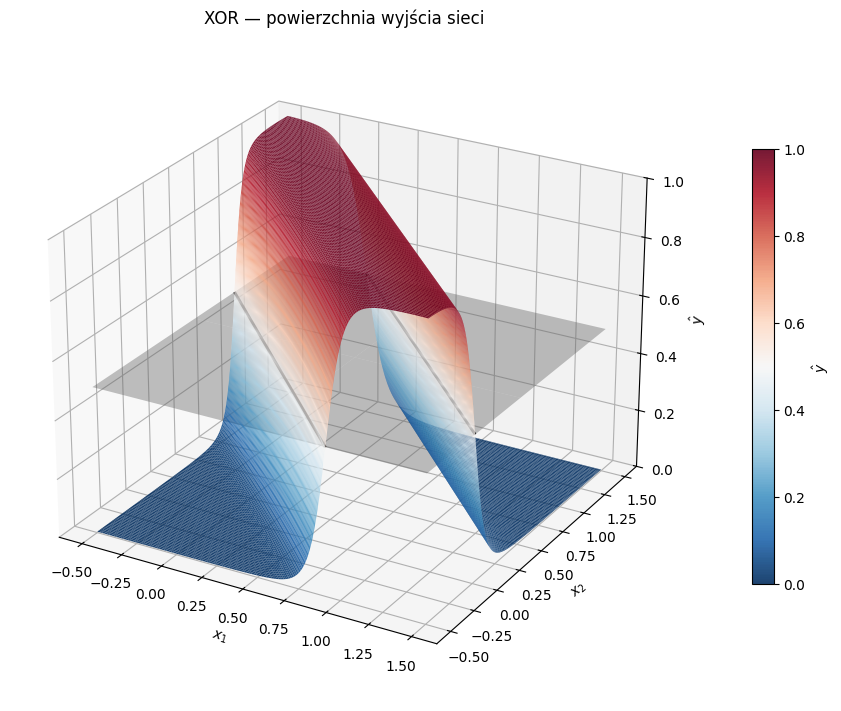

In [ ]:

### wykres 3D ###
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    x1, x2, output,
    cmap="RdBu_r", vmin=0, vmax=1,
    alpha=0.9, linewidth=0,
    rcount=150, ccount=150,
)

# Płaszczyzna progu klasyfikacji
ax.plot_surface(
    x1, x2, np.full_like(output, 0.5),
    color="gray", alpha=0.4,
    rcount=2, ccount=2,
)

# Rzeczywista granica na wysokości 0.5
ax.contour(
    x1, x2, output,
    levels=[0.5], colors="black", linewidths=2,
)

ax.set(
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$\hat{y}$",
    zlim=(0, 1),
    title="XOR — powierzchnia wyjścia sieci",
)
ax.view_init(elev=25, azim=-60)

fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1,
             label=r"$\hat{y}$")
plt.show()
